# Data cleaning and encoding

In [1]:
# --- IMPORTS AND SETUP ---
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import warnings

# Configuration settings
pd.set_option('display.float_format', lambda x: '%.f' % x)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
warnings.filterwarnings('ignore') # Suppress warnings

# Read Dataset
ranaghulamnabi_shopping_behavior_and_preferences_study_path = kagglehub.dataset_download('ranaghulamnabi/shopping-behavior-and-preferences-study')
df = pd.read_csv(f'{ranaghulamnabi_shopping_behavior_and_preferences_study_path}/shopping_behavior_updated.csv')
data = df.copy() # Store a copy of the original data

# --- DATA CLEANING AND ENCODING ---

# Case Conversion and Whitespace Removal
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
# df = df.drop('Customer ID', axis=1) # Drop ID early

# 1. Binary Encoding (Gender, Subscription Status, Discount Applied, Promo Code Used)
df['Gender'] = df['Gender'].map({'male': 1, 'female': 0})
df['Subscription Status'] = df['Subscription Status'].map({'yes': 1, 'no': 0})
df['Discount Applied'] = df['Discount Applied'].map({'yes': 1, 'no': 0})
df['Promo Code Used'] = df['Promo Code Used'].map({'yes': 1, 'no': 0})

# 2. Ordinal Encoding ('Size' and 'Frequency of Purchases')
size_mapping = {'s': 0, 'm': 1, 'l': 2, 'xl': 3}
df['Size'] = df['Size'].map(size_mapping)

frequency_mapping = {
    'annually': 1, 'every 3 months': 4, 'quarterly': 4,
    'monthly': 12, 'fortnightly': 26, 'bi-weekly': 26, 'weekly': 52
}
df['Frequency of Purchases'] = df['Frequency of Purchases'].map(frequency_mapping)
df_encoded = df.copy()

# 3. One-Hot Encoding (Remaining Nominal Categorical Columns)
columns_for_one_hot_encoding = [
    'Category', 'Season', 'Shipping Type', 'Payment Method'#, 'Color'
]
df_encoded = pd.get_dummies(df, columns=columns_for_one_hot_encoding, drop_first=True)

# 4. Feature Creation (Bins and Sentiment - kept for completeness, though not used in clustering yet)
bins = 3
labels = ['low', 'medium', 'high']
df_encoded['Purchase_Amount_Bins'] = pd.qcut(df_encoded['Purchase Amount (USD)'], q=bins, labels=labels)

age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_encoded['Age_Group'] = pd.cut(df_encoded['Age'], bins=age_bins, labels=age_labels, right=False)

review_bins = [1, 3, 4, 5.1]
review_labels = ['negative', 'neutral', 'positive']
df_encoded['Review_Sentiment'] = pd.cut(df_encoded['Review Rating'], bins=review_bins, labels=review_labels, right=False)

print("Data Cleaning and Encoding Complete. Final DataFrame is df_encoded.")

Using Colab cache for faster access to the 'shopping-behavior-and-preferences-study' dataset.
Data Cleaning and Encoding Complete. Final DataFrame is df_encoded.


# Exploratory Data Analysis (EDA)

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   int64  
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   int64  
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   int64  
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   int64  
 14  Promo Code Used

,Column,Unique Values Count,Unique Values
0,Age,53,"[55, 19, 50, 21, 45, 46, 63, 27, 26, 57, 53, 30, 61, 65, 64, 25, 52, 66, 31, 56, 18, 38, 54, 33, 36, 35, 29, 70, 69, 67, 20, 39, 42, 68, 49, 59, 47, 40, 41, 48, 22, 24, 44, 37, 58, 32, 62, 51, 28, 43, 34, 23, 60]"
1,Gender,2,"[1, 0]"
2,Item Purchased,25,"[blouse, sweater, jeans, sandals, sneakers, shirt, shorts, coat, handbag, shoes, dress, skirt, sunglasses, pants, jacket, hoodie, jewelry, t-shirt, scarf, hat, socks, backpack, belt, boots, gloves]"
3,Category,4,"[clothing, footwear, outerwear, accessories]"
4,Purchase Amount (USD),81,"[53, 64, 73, 90, 49, 20, 85, 34, 97, 31, 68, 72, 51, 81, 36, 38, 48, 62, 37, 88, 22, 25, 56, 94, 79, 67, 91, 33, 69, 45, 60, 76, 39, 100, 21, 43, 54, 55, 30, 28, 59, 24, 83, 46, 70, 29, 26, 58, 96, 40, 32, 95, 41, 47, 99, 87, 92, 98, 89, 35, 75, 65, 86, 84, 77, 27, 23, 74, 80, 42, 61, 82, 78, 93, 50, 57, 66, 44, 52, 71, 63]"
5,Location,50,"[kentucky, maine, massachusetts, rhode island, oregon, wyoming, montana, louisiana, west virginia, missouri, arkansas, hawaii, delaware, new hampshire, new york, alabama, mississippi, north carolina, california, oklahoma, florida, texas, nevada, kansas, colorado, north dakota, illinois, indiana, arizona, alaska, tennessee, ohio, new jersey, maryland, vermont, new mexico, south carolina, idaho, pennsylvania, connecticut, utah, virginia, georgia, nebraska, iowa, south dakota, minnesota, washington, wisconsin, michigan]"
6,Size,4,"[2, 0, 1, 3]"
7,Color,25,"[gray, maroon, turquoise, white, charcoal, silver, pink, purple, olive, gold, violet, teal, lavender, black, green, peach, red, cyan, brown, beige, orange, indigo, yellow, magenta, blue]"
8,Season,4,"[winter, spring, summer, fall]"
9,Review Rating,26,"[3.1, 3.5, 2.7, 2.9, 3.2, 2.6, 4.8, 4.1, 4.9, 4.5, 4.7, 2.8, 4.6, 3.3, 4.4, 3.6, 5.0, 4.0, 3.7, 4.2, 3.9, 3.0, 3.8, 3.4, 4.3, 2.5]"



--- 1. Purchase Amount (USD) Analysis ---


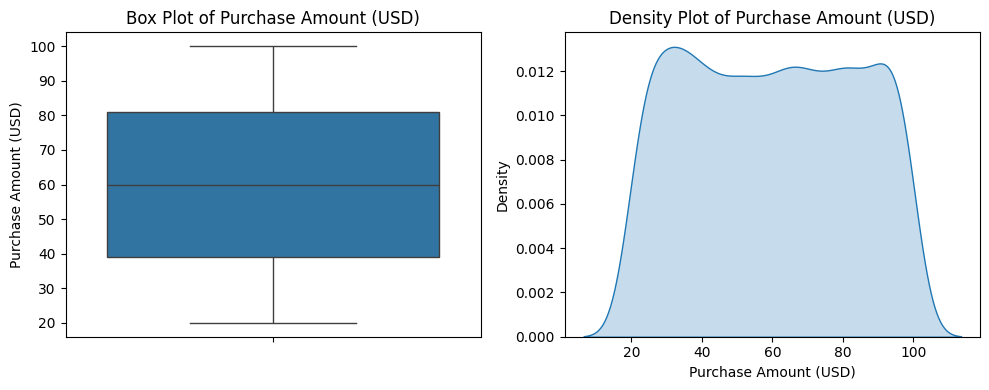

Descriptive Statistics:
count   3900
mean      60
std       24
min       20
25%       39
50%       60
75%       81
max      100
Name: Purchase Amount (USD), dtype: float64

Outliers above 1.5*IQR (144.00): 0

--- 2. Previous Purchases Analysis ---


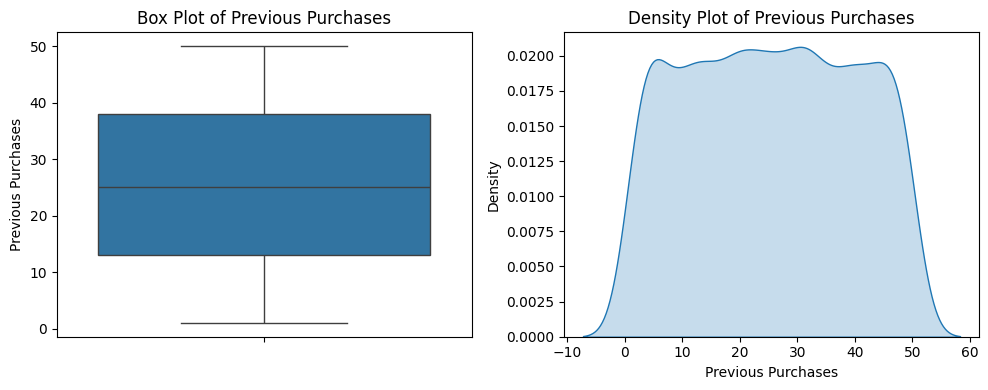

Descriptive Statistics:
count   3900
mean      25
std       14
min        1
25%       13
50%       25
75%       38
max       50
Name: Previous Purchases, dtype: float64

Outliers above 1.5*IQR (75.50): 0

--- 3. Review Rating & Sentiment Analysis ---


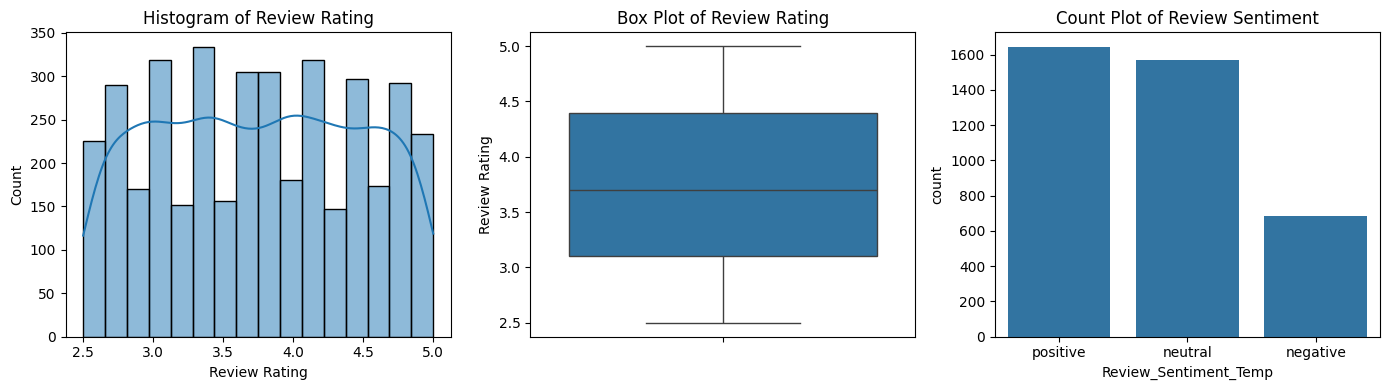


--- 4. Age and Age Group Analysis ---


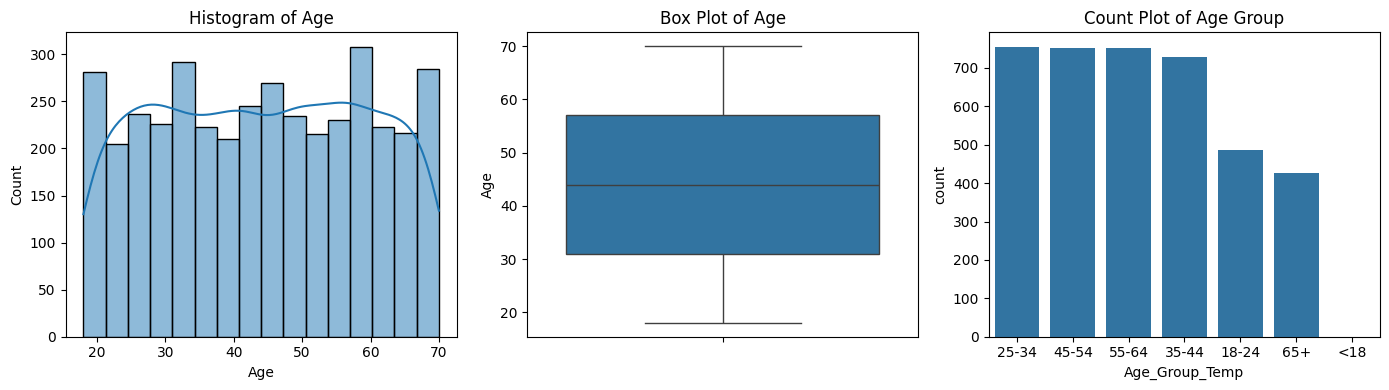


--- 5. Distribution of Key Categorical Variables ---


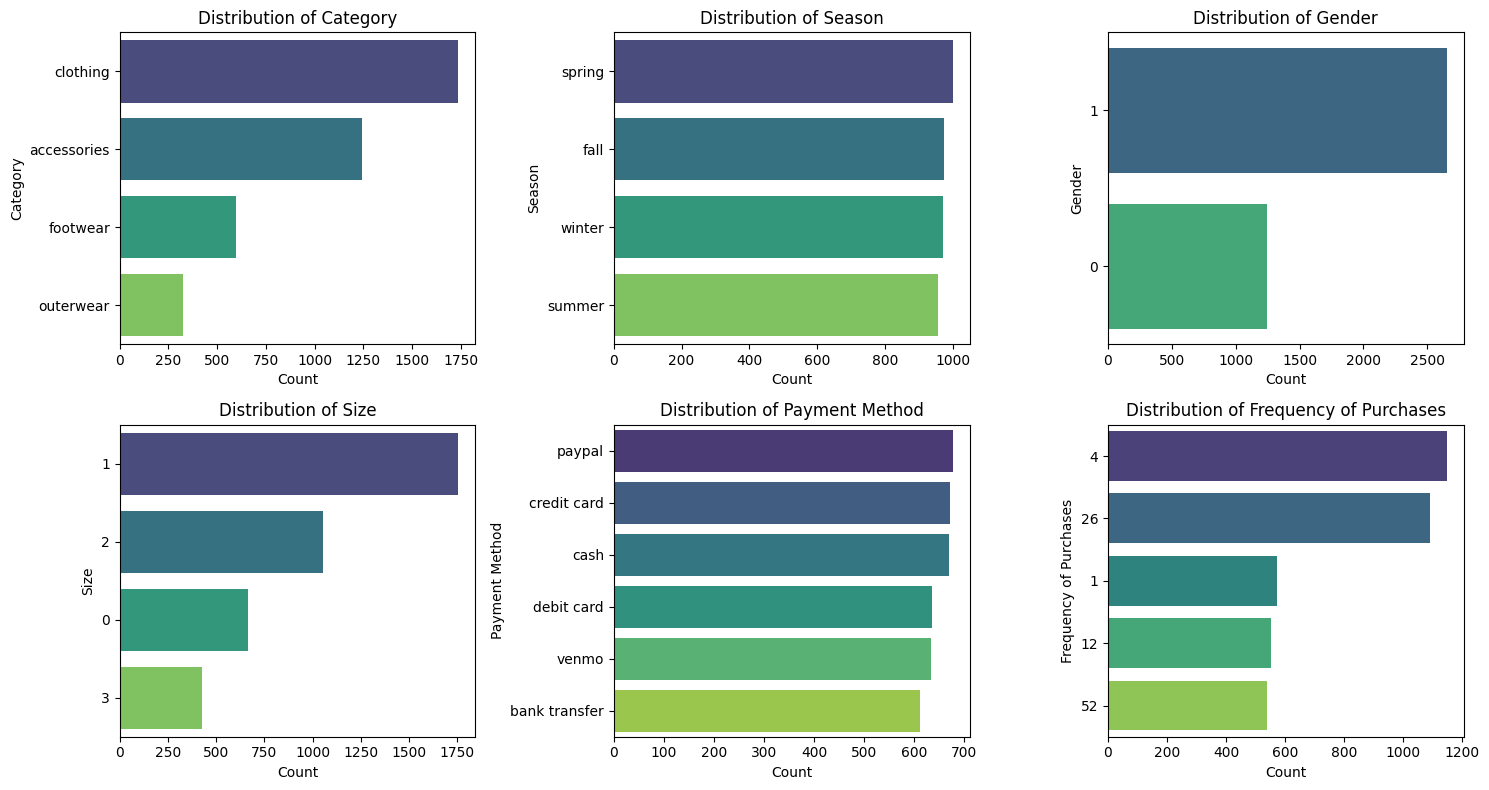


--- 6. Correlation Matrix of Numerical Features (from df_encoded) ---


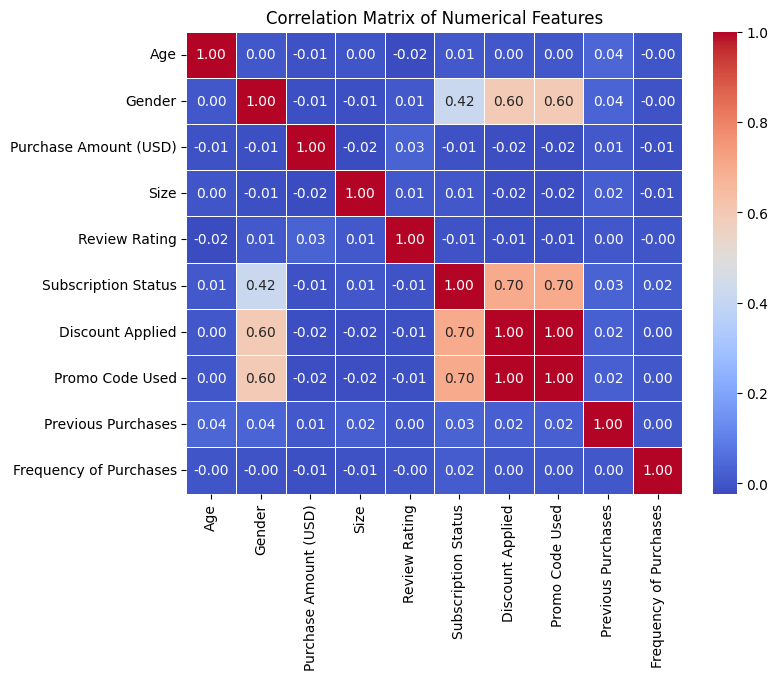

Interpretation: Low correlation values indicate weak linear relationships between the raw numerical features.

--- 7. Segmented Distributions ---


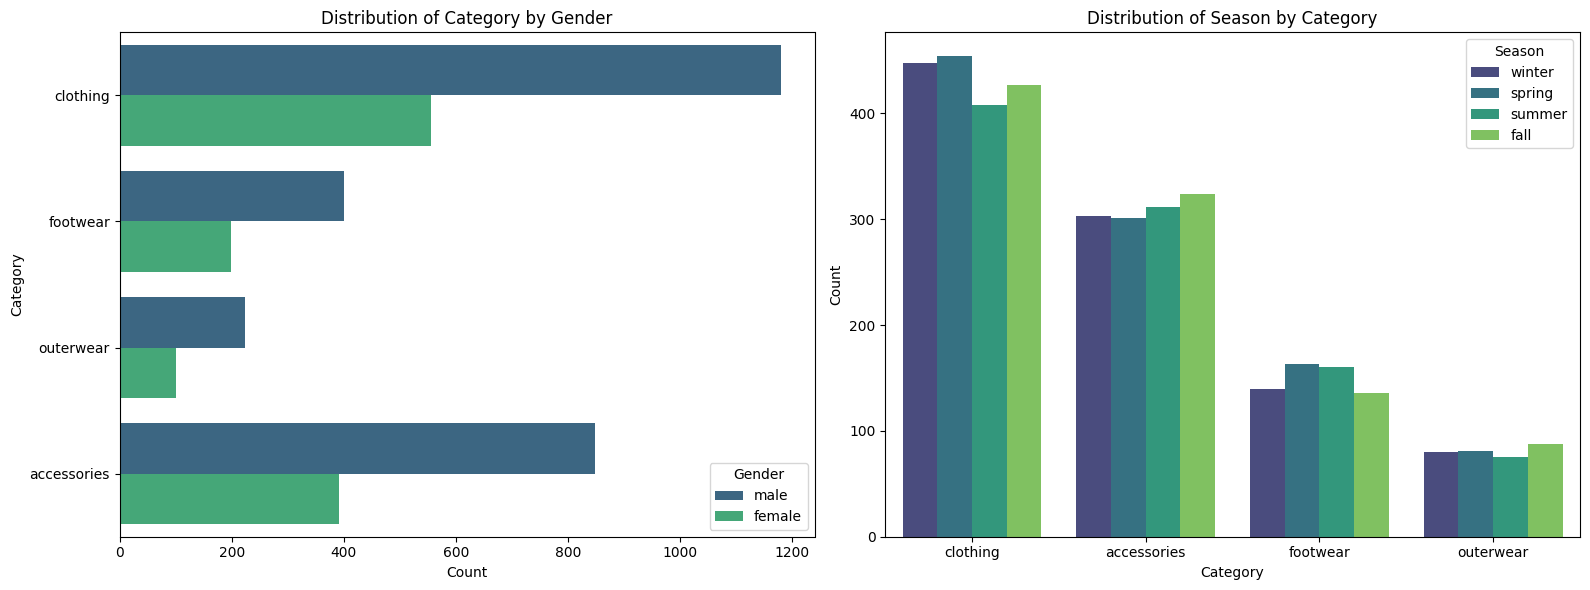


--- 8. Purchase Amount Comparisons ---


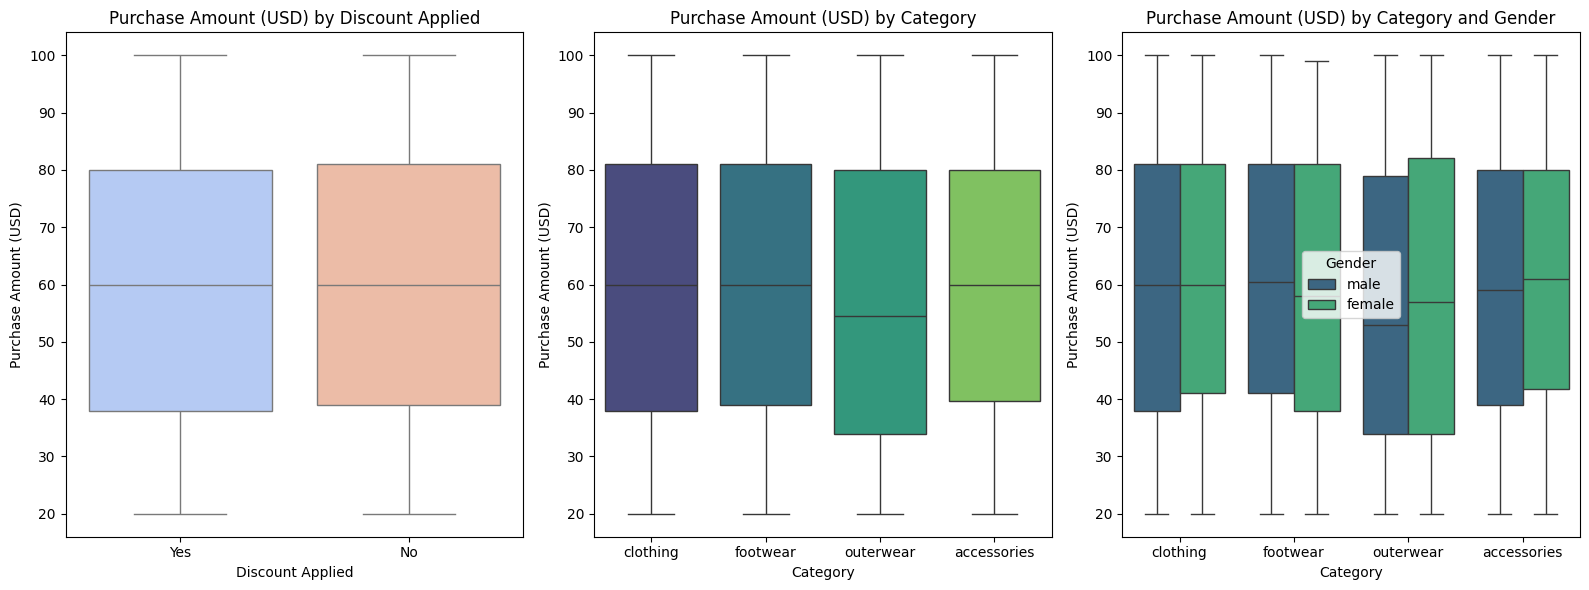


EDA and Data Inspection consolidation complete.


In [2]:
# --- DATA INSPECTION AND SUMMARY ---

print("--- Data Information ---")
df.info()

# Dropping 'Customer ID' as noted in the inferences
df = df.drop('Customer ID', axis=1, errors='ignore')

# Inspecting Unique Values Per Column
categorical_cols = df.select_dtypes(include='object').columns
unique_values_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique Values Count': [df[col_name].nunique() for col_name in df.columns],
    'Unique Values': [df[col_name].unique() for col_name in df.columns]
})
print("\n--- Unique Values Summary ---")
display(unique_values_summary)

# --- OUTLIER ANALYSIS AND DISTRIBUTION ---

# 1. Purchase Amount (USD)
print("\n--- 1. Purchase Amount (USD) Analysis ---")
plt.figure(figsize=(10, 4))

# Subplot 1: Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Purchase Amount (USD)'])
plt.title('Box Plot of Purchase Amount (USD)')

# Subplot 2: Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(df['Purchase Amount (USD)'], fill=True)
plt.title('Density Plot of Purchase Amount (USD)')

plt.tight_layout()
plt.show()

# IQR Outlier Check
Q1 = df['Purchase Amount (USD)'].quantile(0.25)
Q3 = df['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Purchase Amount (USD)'] > upper_bound)]
print(f"Descriptive Statistics:\n{df['Purchase Amount (USD)'].describe()}")
print(f"\nOutliers above 1.5*IQR ({upper_bound:.2f}): {len(outliers)}")


# 2. Previous Purchases
print("\n--- 2. Previous Purchases Analysis ---")
plt.figure(figsize=(10, 4))

# Subplot 1: Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Previous Purchases'])
plt.title('Box Plot of Previous Purchases')

# Subplot 2: Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(df['Previous Purchases'], fill=True)
plt.title('Density Plot of Previous Purchases')

plt.tight_layout()
plt.show()

# IQR Outlier Check
Q3_prev = df['Previous Purchases'].quantile(0.75)
IQR_prev = Q3_prev - df['Previous Purchases'].quantile(0.25)
upper_bound_prev = Q3_prev + 1.5 * IQR_prev
outliers_prev = df[(df['Previous Purchases'] > upper_bound_prev)]
print(f"Descriptive Statistics:\n{df['Previous Purchases'].describe()}")
print(f"\nOutliers above 1.5*IQR ({upper_bound_prev:.2f}): {len(outliers_prev)}")


# --- UNIVARIATE ANALYSIS (Review Rating and Age) ---

print("\n--- 3. Review Rating & Sentiment Analysis ---")
plt.figure(figsize=(14, 4))

# Subplot 1: Histogram for Review Rating
plt.subplot(1, 3, 1)
sns.histplot(df['Review Rating'], kde=True)
plt.title('Histogram of Review Rating')

# Subplot 2: Box Plot for Review Rating
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Review Rating'])
plt.title('Box Plot of Review Rating')

# Subplot 3: Count Plot of Review Sentiment
review_bins = [1, 3, 4, 5.1]
review_labels = ['negative', 'neutral', 'positive']
df['Review_Sentiment_Temp'] = pd.cut(df['Review Rating'], bins=review_bins, labels=review_labels, right=False)
plt.subplot(1, 3, 3)
sns.countplot(x=df['Review_Sentiment_Temp'], order=df['Review_Sentiment_Temp'].value_counts().index)
plt.title('Count Plot of Review Sentiment')
df.drop('Review_Sentiment_Temp', axis=1, inplace=True) # Drop temp column

plt.tight_layout()
plt.show()


print("\n--- 4. Age and Age Group Analysis ---")
plt.figure(figsize=(14, 4))

# Subplot 1: Histogram for Age
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Histogram of Age')

# Subplot 2: Box Plot for Age
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')

# Subplot 3: Count Plot of Age Group (Using temporary cut on df)
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group_Temp'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
plt.subplot(1, 3, 3)
sns.countplot(x=df['Age_Group_Temp'], order=df['Age_Group_Temp'].value_counts().index)
plt.title('Count Plot of Age Group')
df.drop('Age_Group_Temp', axis=1, inplace=True) # Drop temp column

plt.tight_layout()
plt.show()


# --- MULTIVARIATE ANALYSIS (BAR CHARTS) ---

print("\n--- 5. Distribution of Key Categorical Variables ---")
columns_to_plot = [
    'Category', 'Season', 'Gender', 'Size',
    'Payment Method', 'Frequency of Purchases'
]

# Create a figure to hold all count plots
n_cols = 3
n_rows = int(np.ceil(len(columns_to_plot) / n_cols))
plt.figure(figsize=(15, 4 * n_rows)) # Adjust figure size dynamically

for i, col in enumerate(columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    # Use df for plotting as it contains original categorical values
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


# --- CORRELATION MATRIX (using df_encoded) ---

print("\n--- 6. Correlation Matrix of Numerical Features (from df_encoded) ---")
numerical_cols = df.select_dtypes(include=['number']).columns # Use original df numerical columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Interpretation: Low correlation values indicate weak linear relationships between the raw numerical features.")


# --- SEGMENTED DISTRIBUTIONS ---

print("\n--- 7. Segmented Distributions ---")
plt.figure(figsize=(16, 6))

# Subplot 1: Distribution of Category by Gender
plt.subplot(1, 2, 1)
sns.countplot(y=df['Category'], hue=df['Gender'].map({1: 'male', 0: 'female'}), palette='viridis')
plt.title('Distribution of Category by Gender')
plt.xlabel('Count')
plt.ylabel('Category')
plt.legend(title='Gender')

# Subplot 2: Distribution Plot of Season by Category
plt.subplot(1, 2, 2)
sns.countplot(x=df['Category'], hue=df['Season'], palette='viridis', order=df['Category'].value_counts().index)
plt.title('Distribution of Season by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Season')

plt.tight_layout()
plt.show()


# --- PURCHASE AMOUNT COMPARISONS ---

print("\n--- 8. Purchase Amount Comparisons ---")
plt.figure(figsize=(16, 6))

# Subplot 1: Purchase Amount by Discount/Promo Code (Requires encoded columns from df_encoded)
plt.subplot(1, 3, 1)
sns.boxplot(x=df['Discount Applied'].map({1: 'Yes', 0: 'No'}), y=df['Purchase Amount (USD)'], palette='coolwarm')
plt.title('Purchase Amount (USD) by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Purchase Amount (USD)')

# Subplot 2: Purchase Amount by Category
plt.subplot(1, 3, 2)
sns.boxplot(x='Category', y='Purchase Amount (USD)', data=df, palette='viridis')
plt.title('Purchase Amount (USD) by Category')
plt.xlabel('Category')
plt.ylabel('Purchase Amount (USD)')

# Subplot 3: Purchase Amount (USD) Segmented by Gender and Category
plt.subplot(1, 3, 3)
sns.boxplot(x=df['Category'], y=df['Purchase Amount (USD)'], hue=df['Gender'].map({1: 'male', 0: 'female'}), palette='viridis')
plt.title('Purchase Amount (USD) by Category and Gender')
plt.xlabel('Category')
plt.ylabel('Purchase Amount (USD)')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

print("\nEDA and Data Inspection consolidation complete.")

In [ ]:
df_encoded.to_csv('df_encoded.csv', index=False)
print("df_encoded.csv has been saved. Click the 'Files' icon on the left sidebar to download it.")

df_encoded.csv has been saved. Click the 'Files' icon on the left sidebar to download it.


# Customer Segmentation (K-Means Clustering)

In [3]:
# --- 1. FEATURE SELECTION AND SCALING ---

# The four features requested by the user
clustering_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

X_clustering = df_encoded[clustering_features].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

print(f"Clustering data prepared with features: {clustering_features}")

# --- 2. FINAL K-MEANS CLUSTERING (K=4) ---

K_final = 4
kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)
cluster_labels_final = kmeans_final.labels_

# Assign the new cluster labels back to the DataFrame
cluster_column_name = 'Cluster_4Features'
df_encoded[cluster_column_name] = cluster_labels_final

print(f"K-Means clustering with K={K_final} successful. Labels stored in '{cluster_column_name}'.")

# --- 3. CLUSTER PROFILE COMPARISON ---

# Define all key features for profiling
profiling_features = clustering_features + [
    'Subscription Status',
    'Discount Applied',
    'Frequency of Purchases'
]

# Calculate the mean of key features, grouped by the new cluster
df_profile_numeric = df_encoded.groupby(cluster_column_name)[profiling_features].mean().reset_index()

# Round to 2 decimal places for clean display
df_profile_numeric = df_profile_numeric.round(2)

print("\n--- Final Segment Profiles (K=4, Age, Purchase, Review, Previous Purchases) ---")
print("These profiles show the mean values of key features for the new clusters:")
print(df_profile_numeric.to_markdown(index=False, numalign="left", stralign="left"))

# Output the final encoded CSV with the new cluster for potential future use
df_encoded.to_csv('df_encoded_4features_k4.csv', index=False)
print("\nNew cluster column added and saved to 'df_encoded_4features_k4.csv'.")

Clustering data prepared with features: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
K-Means clustering with K=4 successful. Labels stored in 'Cluster_4Features'.

--- Final Segment Profiles (K=4, Age, Purchase, Review, Previous Purchases) ---
These profiles show the mean values of key features for the new clusters:
| Cluster_4Features   | Age   | Purchase Amount (USD)   | Review Rating   | Previous Purchases   | Subscription Status   | Discount Applied   | Frequency of Purchases   |
|:--------------------|:------|:------------------------|:----------------|:---------------------|:----------------------|:-------------------|:-------------------------|
| 0                   | 56.22 | 82.08                   | 3.96            | 26.76                | 0.27                  | 0.42               | 16.98                    |
| 1                   | 31.33 | 54.86                   | 4.43            | 24.98                | 0.26                  | 0.42               

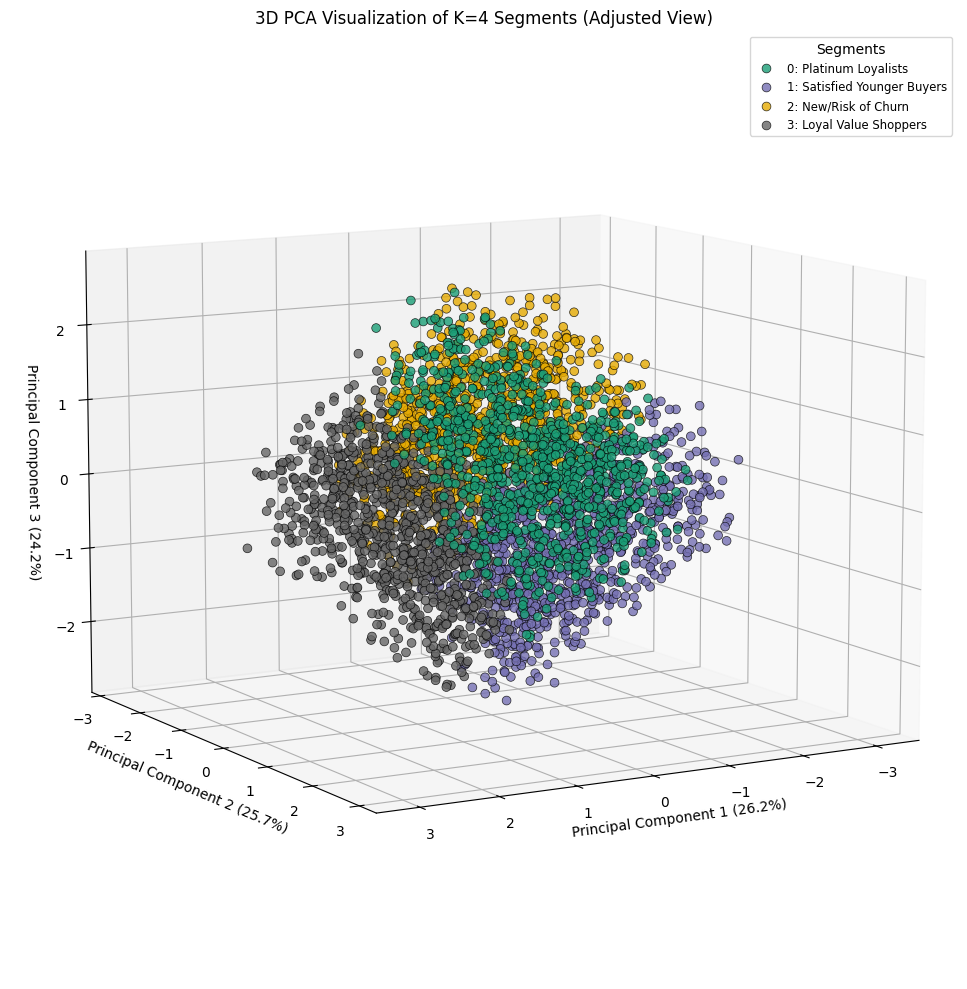

Revised 3D PCA visualization generated successfully.


In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# --- 1. PREPARE DATA FOR 3D PCA ---

# The four features used for clustering
clustering_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
cluster_column = 'Cluster_4Features'

X_clustering = df_encoded[clustering_features].copy()
y_clusters = df_encoded[cluster_column].astype('category')

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# --- 2. RUN PCA (N=3 Components) ---
# Reduce the 4 dimensions to 3 Principal Components for visualization
pca_3d = PCA(n_components=3)
principal_components_3d = pca_3d.fit_transform(X_scaled)

df_pca_3d = pd.DataFrame(data=principal_components_3d,
                         columns=['PC1', 'PC2', 'PC3'])
df_pca_3d[cluster_column] = y_clusters.values

# --- 3. GENERATE 3D SCATTER PLOT (Adjusted View) ---

fig = plt.figure(figsize=(12, 10)) # Slightly larger figure
ax = fig.add_subplot(111, projection='3d')

# Define colors and labels
unique_clusters = sorted(df_pca_3d[cluster_column].unique())
# Use a colorblind-friendly palette, e.g., 'Dark2' for better distinction
colors = plt.cm.Dark2(np.linspace(0, 1, len(unique_clusters)))
cluster_names = {
    0: '0: Platinum Loyalists',
    1: '1: Satisfied Younger Buyers',
    2: '2: New/Risk of Churn',
    3: '3: Loyal Value Shoppers'
}

for i, cluster in enumerate(unique_clusters):
    subset = df_pca_3d[df_pca_3d[cluster_column] == cluster]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               c=colors[i], label=cluster_names[cluster],
               s=40, alpha=0.8, edgecolors='k', linewidth=0.5) # Larger points, darker edges

ax.set_xlabel(f'Principal Component 1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'Principal Component 2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'Principal Component 3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title(f'3D PCA Visualization of K=4 Segments (Adjusted View)')
ax.legend(title='Segments', loc='best', fontsize='small')

# New viewing angle for better separation (Lower elevation, different rotation)
ax.view_init(elev=10, azim=60)

plt.tight_layout()
plt.savefig('3d_pca_cluster_visualization_v2.png')
plt.show()

print("Revised 3D PCA visualization generated successfully.")

In [ ]:
df_encoded.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases,Category_clothing,Category_footwear,Category_outerwear,Season_spring,Season_summer,Season_winter,Shipping Type_express,Shipping Type_free shipping,Shipping Type_next day air,Shipping Type_standard,Shipping Type_store pickup,Payment Method_cash,Payment Method_credit card,Payment Method_debit card,Payment Method_paypal,Payment Method_venmo,Purchase_Amount_Bins,Age_Group,Review_Sentiment,Cluster_4Features
0,1,55,1,blouse,53,kentucky,2,gray,3,1,1,1,14,26,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,medium,55-64,neutral,3
1,2,19,1,sweater,64,maine,2,maroon,3,1,1,1,2,26,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,medium,18-24,neutral,2
2,3,50,1,jeans,73,massachusetts,0,maroon,3,1,1,1,23,52,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,medium,45-54,neutral,2
3,4,21,1,sandals,90,rhode island,1,maroon,4,1,1,1,49,52,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,high,18-24,neutral,2
4,5,45,1,blouse,49,oregon,1,turquoise,3,1,1,1,31,1,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,medium,45-54,negative,2


# Purchase Amount Regression Model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load Data
df_regression = df_encoded.copy()

# 2. Define Target and Features
# Drop 'Purchase Amount (USD)' as it's the target variable
# Drop 'Customer ID' as it's an identifier
# Drop derived categorical features (bins, groups, sentiment) as they are redundant or not directly suitable for regression with numerical models
# Drop 'Cluster_4Features' as it's a result of clustering and not an original feature for this regression task
columns_to_drop = [
    'Purchase Amount (USD)', 'Customer ID', 'Purchase_Amount_Bins',
    'Age_Group', 'Review_Sentiment', 'Cluster_4Features'
]
X = df_regression.drop(columns=columns_to_drop)
y = df_regression['Purchase Amount (USD)']

# Identify remaining categorical columns for one-hot encoding
categorical_cols_for_ohe = X.select_dtypes(include='object').columns

# Apply One-Hot Encoding to the identified categorical columns
X = pd.get_dummies(X, columns=categorical_cols_for_ohe, drop_first=True)

# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regressor": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 5. Loop and Evaluate
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))
    })

# 6. Display Table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, formatters={
    'R2': '{:,.3f}'.format,
    'MAE': '{:,.3f}'.format,
    'RMSE': '{:,.3f}'.format
}))

                   Model     R2    MAE   RMSE
       Linear Regression -0.026 20.855 23.959
Support Vector Regressor -0.006 20.774 23.721
           Random Forest -0.034 21.011 24.059


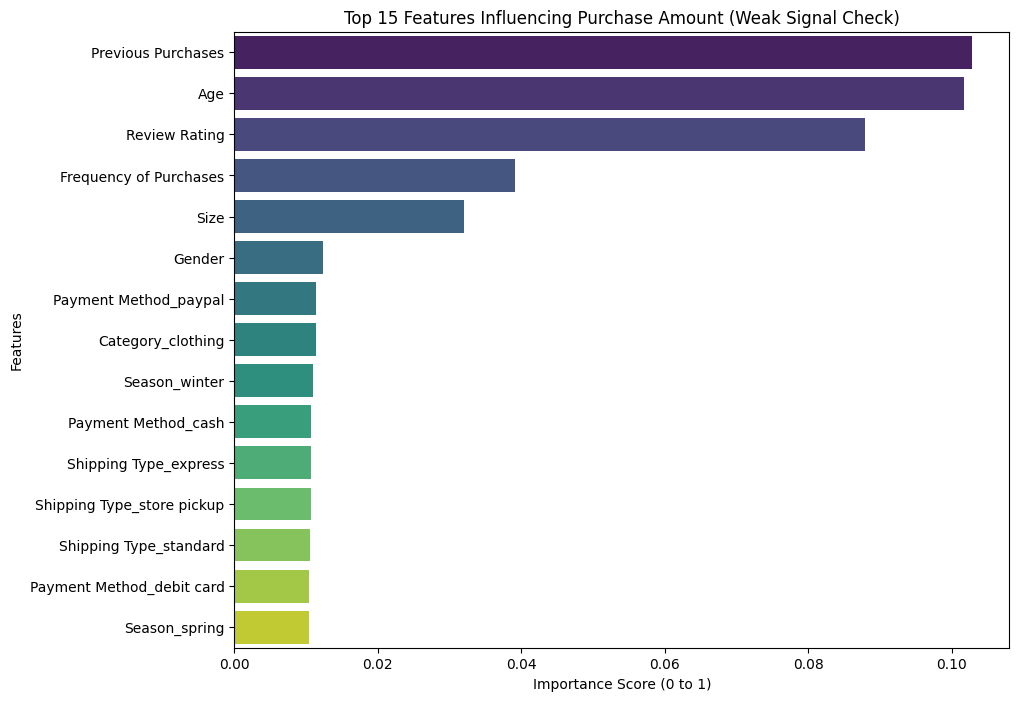

                   Feature  Importance
7       Previous Purchases           0
0                      Age           0
3            Review Rating           0
8   Frequency of Purchases           0
2                     Size           0
1                   Gender           0
23   Payment Method_paypal           0
9        Category_clothing           0
14           Season_winter           0
20     Payment Method_cash           0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fit the Random Forest model
rf_model = models["Random Forest"]
rf_model.fit(X_train_scaled, y_train)

# 2. Extract Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns

# 3. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Features Influencing Purchase Amount (Weak Signal Check)')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Features')
plt.show()

# Display the numerical values
print(feature_importance_df.head(10))

Regression analysis confirms that demographic and behavioral features (Age, Gender, Category) have no predictive relationship with Purchase Amount ($R^2 \approx 0$). This suggests a highly diversified customer base where spending is independent of traditional segments

# Finding relationship between Gender and Category

In [7]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create a Cross-tabulation (Contingency Table)
contingency_table = pd.crosstab(df['Gender'], df['Category'])

# 2. Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

if p < 0.05:
    print("Result: Significant relationship found between Gender and Category!")
else:
    print("Result: No significant relationship found.")

Chi-Square Statistic: 0.598
P-value: 0.89679
Result: No significant relationship found.


# Calculating Average spent per year

--- Frequency vs. Spending Analysis ---
                        Purchase Amount (USD)  Est_Annual_Spend  \
Frequency of Purchases                                            
52                                         59              3067   
26                                         60              1557   
12                                         59               712   
4                                          60               240   
1                                          60                60   

                        Customer_Count  
Frequency of Purchases                  
52                                 539  
26                                1089  
12                                 553  
4                                 1147  
1                                  572  


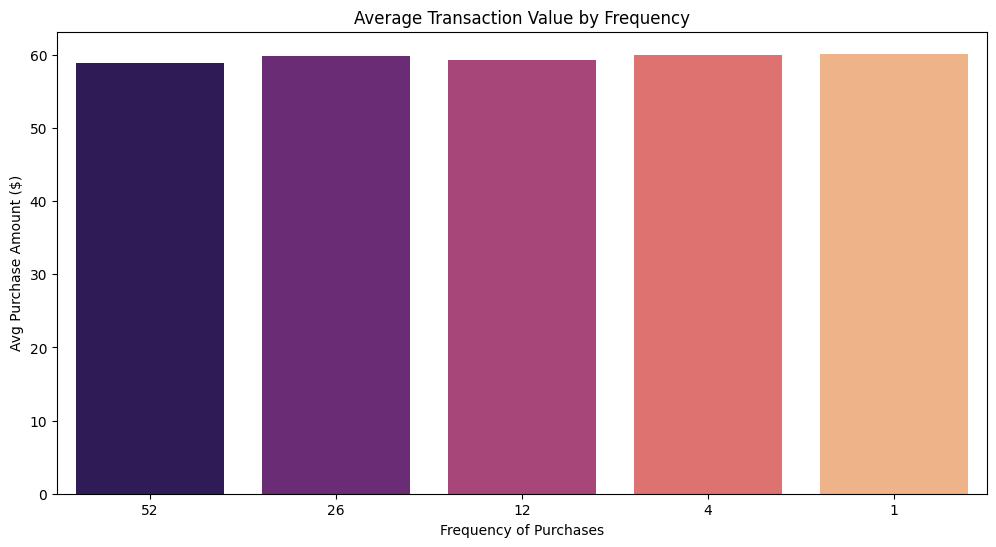


ANOVA P-value: 0.8893


In [9]:
from scipy.stats import f_oneway

# Calculate Estimated Annual Spend
df_encoded['Est_Annual_Spend'] = df_encoded['Purchase Amount (USD)'] * df_encoded['Frequency of Purchases']

# Aggregate Stats by Frequency
freq_analysis = df_encoded.groupby('Frequency of Purchases').agg({
    'Purchase Amount (USD)': 'mean',
    'Est_Annual_Spend': 'mean',
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Customer_Count'}).sort_values(by='Est_Annual_Spend', ascending=False)

print("--- Frequency vs. Spending Analysis ---")
print(freq_analysis.round(2))

# Visualization: Average Spend per Transaction
plt.figure(figsize=(12, 6))
sns.barplot(x=freq_analysis.index.astype(str), y='Purchase Amount (USD)', data=freq_analysis, palette='magma')
plt.title('Average Transaction Value by Frequency')
plt.ylabel('Avg Purchase Amount ($)')
plt.show()

# Statistical Significance (ANOVA)
# Testing if 'Purchase Amount' actually changes based on 'Frequency'
groups = [df_encoded[df_encoded['Frequency of Purchases'] == f]['Purchase Amount (USD)'] for f in df_encoded['Frequency of Purchases'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"\nANOVA P-value: {p_val:.4f}")

# T-Test on  "Promo Code Used"

--- Promo Code Impact Analysis ---
Mean Spend (With Promo): $59.28
Mean Spend (No Promo):   $60.13
T-Statistic: -1.1114
P-Value: 0.2665


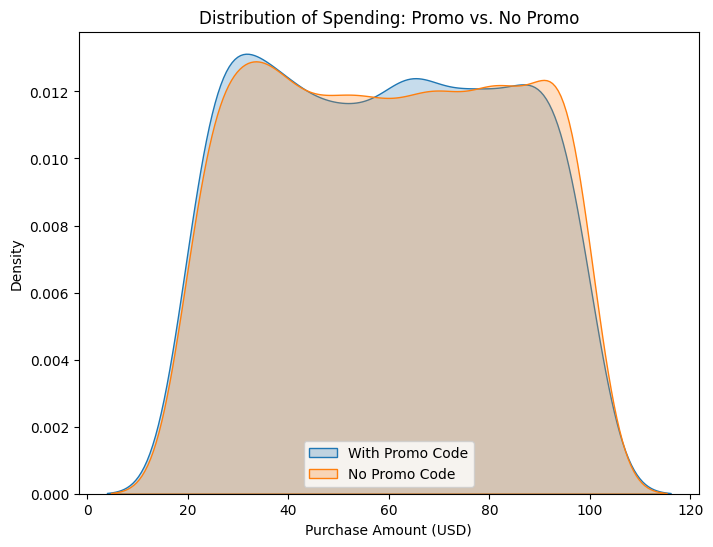

In [12]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Split the Purchase Amount into two groups using the encoded values (1 for 'yes', 0 for 'no')
promo_yes = df_encoded[df_encoded['Promo Code Used'] == 1]['Purchase Amount (USD)']
promo_no = df_encoded[df_encoded['Promo Code Used'] == 0]['Purchase Amount (USD)']

# Calculate Means
mean_yes = promo_yes.mean()
mean_no = promo_no.mean()

# Perform the T-Test
# Check if both groups have enough data to perform the t-test
if len(promo_yes) > 1 and len(promo_no) > 1:
    t_stat, p_val = stats.ttest_ind(promo_yes, promo_no)
else:
    t_stat = float('nan')
    p_val = float('nan')

print(f"--- Promo Code Impact Analysis ---")
print(f"Mean Spend (With Promo): ${mean_yes:.2f}")
print(f"Mean Spend (No Promo):   ${mean_no:.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

# Visualization
plt.figure(figsize=(8, 6))
sns.kdeplot(promo_yes, label='With Promo Code', shade=True)
sns.kdeplot(promo_no, label='No Promo Code', shade=True)
plt.title('Distribution of Spending: Promo vs. No Promo')
plt.xlabel('Purchase Amount (USD)')
plt.legend()
plt.show()